# SLEAP × mPFC Spike Exploration
Correlates continuous mPFC firing rates with SLEAP-derived social features.

**Alignment**: SLEAP `time_ms` is used to bin features into 50ms windows matching the spike timebin.  
**Unit-level**: Spearman r between each unit's firing rate and each feature, across all timepoints.  
**Population-level**: Spearman r between mean firing rate across all units and each feature, per session.

In [10]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy import stats
import sys
import os

from spike.spike_analysis.spike_collection import SpikeCollection

## Load data

In [11]:
SPIKE_COLLECTION_PATH = r'C:\Users\megha\UF Dropbox\Meghan Cum\Padilla-Coreano Lab\2024\Cum_SocialMemEphys_pilot2\only_subjects_spike_collection\spike_collection.json'
SLEAP_DICT_PATH       = r'C:\Users\megha\Documents\GitHub\diff_fam_social_memory_ephys\pilot2\only_subjects\paired_sleap_dicts.pkl'

spike_collection = SpikeCollection.load_collection(SPIKE_COLLECTION_PATH)

with open(SLEAP_DICT_PATH, 'rb') as f:
    sleap_dicts = pickle.load(f)

print(f'Loaded {len(spike_collection.recordings)} spike recordings')
print(f'Spike recording names: {[r.name for r in spike_collection.recordings]}')
print(f'SLEAP dict keys: {list(sleap_dicts.keys())}')

Loaded 15 spike recordings
Spike recording names: ['11_CNF_merged.rec', '11_NCF_merged.rec', '12_CNF_merged.rec', '13_NCF_merged.rec', '21_FCN_merged.rec', '21_NCF_merged.rec', '22_FCN_merged.rec', '22_NCF_merged.rec', '23_CNF_merged.rec', '23_NFC_merged.rec', '24_CNF_merged.rec', '24_NFC_merged.rec', '32_NFC_merged.rec', '41_FCN_merged.rec', '44_FCN_merged.rec']
SLEAP dict keys: ['11_CNF_merged.rec', '12_CNF_merged.rec', '23_CNF_merged.rec', '24_CNF_merged.rec', '11_NCF_merged.rec', '13_NCF_merged.rec', '21_NCF_merged.rec', '22_NCF_merged.rec', '21_FCN_merged.rec', '22_FCN_merged.rec', '41_FCN_merged.rec', '44_FCN_merged.rec', '23_NFC_merged.rec', '24_NFC_merged.rec', '31_NFC_merged.rec', '32_NFC_merged.rec']


In [33]:
spike_collection.recording_details()

Recording Details:

Recording: 11_CNF_merged.rec
  Subject: 1.1
  Number of Good Units: 20
  Recording Length: 40.04 minutes
  Events per Event Type: {'baseline': 12, 'cagemate': 47, 'exposure_1': 47, 'exposure_2': 38, 'exposure_3': 39, 'familiar': 39, 'novel': 38}

Recording: 11_NCF_merged.rec
  Subject: 1.1
  Number of Good Units: 13
  Recording Length: 41.71 minutes
  Events per Event Type: {'baseline': 12, 'cagemate': 13, 'exposure_1': 25, 'exposure_2': 13, 'exposure_3': 32, 'familiar': 32, 'novel': 25}

Recording: 12_CNF_merged.rec
  Subject: 1.2
  Number of Good Units: 16
  Recording Length: 40.04 minutes
  Events per Event Type: {'baseline': 12, 'cagemate': 39, 'exposure_1': 39, 'exposure_2': 23, 'exposure_3': 20, 'familiar': 20, 'novel': 23}

Recording: 13_NCF_merged.rec
  Subject: 1.3
  Number of Good Units: 19
  Recording Length: 41.71 minutes
  Events per Event Type: {'baseline': 12, 'cagemate': 18, 'exposure_1': 29, 'exposure_2': 18, 'exposure_3': 9, 'familiar': 9, 'novel':

In [12]:
# Inspect SLEAP dict structure for one recording
example_rec = list(sleap_dicts.keys())[0]
print(f'Example recording: {example_rec}')
print(f'  Keys: {list(sleap_dicts[example_rec].keys())}')
example_agent = list(sleap_dicts[example_rec].keys())[0]
print(f'  Example agent: {example_agent}')
print(f'  Agent keys: {list(sleap_dicts[example_rec][example_agent].keys())}')
print(f'  features_1ms shape: {sleap_dicts[example_rec][example_agent]["features_1ms"].shape}')
print(f'  time_ms shape:      {sleap_dicts[example_rec][example_agent]["time_ms"].shape}')
print(f'  feature_legend:     {sleap_dicts[example_rec][example_agent]["feature_legend"]}')

Example recording: 11_CNF_merged.rec
  Keys: ['cagemate', 'novel', 'familiar']
  Example agent: cagemate
  Agent keys: ['locations_1ms', 'time_ms', 'subject', 'partner', 'features_1ms', 'feature_legend', 'node_dict']
  features_1ms shape: (597592, 11)
  time_ms shape:      (597592,)
  feature_legend:     ['distance', 'velocity_mouse1', 'velocity_mouse2', 'moving_angle_mouse1', 'moving_angle_mouse2', 'front_orientation_mouse1', 'front_orientation_mouse2', 'rump_orientation_mouse1', 'rump_orientation_mouse2', 'body_angle_mouse1', 'body_angle_mouse2']


## Analyze spike collection at 50ms

In [13]:
TIMEBIN = 50  # ms

spike_collection.analyze(
    timebin=TIMEBIN,
    ignore_freq=0.5,
    smoothing_window=None,
    mode='same'
)

for rec in spike_collection.recordings:
    print(f'{rec.name}: {rec.analyzed_neurons} analyzed neurons')

All set to analyze
11_CNF_merged.rec: 14 analyzed neurons
11_NCF_merged.rec: 13 analyzed neurons
12_CNF_merged.rec: 9 analyzed neurons
13_NCF_merged.rec: 18 analyzed neurons
21_FCN_merged.rec: 10 analyzed neurons
21_NCF_merged.rec: 17 analyzed neurons
22_FCN_merged.rec: 14 analyzed neurons
22_NCF_merged.rec: 1 analyzed neurons
23_CNF_merged.rec: 3 analyzed neurons
23_NFC_merged.rec: 1 analyzed neurons
24_CNF_merged.rec: 12 analyzed neurons
24_NFC_merged.rec: 18 analyzed neurons
32_NFC_merged.rec: 9 analyzed neurons
41_FCN_merged.rec: 6 analyzed neurons
44_FCN_merged.rec: 10 analyzed neurons


## Alignment helpers

In [14]:
def build_spike_time_axis(recording, timebin):
    """
    Returns the start time in ms for each spike timebin.
    Uses first_timestamp (in samples) if available, otherwise assumes recording starts at 0.
    """
    n_timebins = len(next(iter(recording.unit_firing_rates.values())))
    start_ms = 0
    return start_ms + np.arange(n_timebins) * timebin  # [n_timebins] #[0, 50, 100, 150] etc. for 50 ms timebin



def bin_sleap_to_spike(sleap_time_ms, sleap_features, spike_time_ms, timebin):
      n_timebins = len(spike_time_ms)
      n_features = sleap_features.shape[1]
      binned     = np.full((n_timebins, n_features), np.nan)

      bin_indices = np.digitize(sleap_time_ms, spike_time_ms) - 1 # figures out which bin each 1ms sleap pose goes into 0-50 = first bin, 50-100 - second bin, minus 1 = 0 indexed?
      valid       = (bin_indices >= 0) & (bin_indices < n_timebins)

      # vectorized grouped mean using pandas (fastest for this pattern)
      import pandas as pd
      df = pd.DataFrame(sleap_features[valid],
                        index=bin_indices[valid])
      means = df.groupby(level=0).mean()

      binned[means.index.values] = means.values
      return binned

## Compute correlations

In [15]:
unit_corr_rows  = []   # one row per unit per feature
pop_corr_rows   = []   # one row per session per feature

for recording in spike_collection.recordings:
    rec_name = recording.name
    subject  = getattr(recording, 'subject', rec_name)

    if rec_name not in sleap_dicts:
        print(f'No SLEAP data for {rec_name}, skipping')
        continue

    if recording.analyzed_neurons == 0:
        print(f'{rec_name}: 0 analyzed neurons, skipping')
        continue

    # build spike time axis
    spike_time_ms = build_spike_time_axis(recording, TIMEBIN)
    print(spike_time_ms[0:100])
    n_timebins    = len(spike_time_ms)

    # stack all SLEAP agents for this recording into one continuous feature array
    # (agent here is cagemate/novel/familiar — pooling all social bouts)
    all_sleap_time     = []
    all_sleap_features = []
    feature_legend     = None

    for agent, agent_info in sleap_dicts[rec_name].items():
        all_sleap_time.append(agent_info['time_ms'])
        all_sleap_features.append(agent_info['features_1ms'])
        feature_legend = agent_info['feature_legend']

    sleap_time_ms  = np.concatenate(all_sleap_time)
    sleap_features = np.vstack(all_sleap_features)

    # sort by time (concatenating agents can scramble order)
    sort_idx       = np.argsort(sleap_time_ms)
    sleap_time_ms  = sleap_time_ms[sort_idx]
    sleap_features = sleap_features[sort_idx]

    # bin SLEAP to spike timebin resolution
    binned_features = bin_sleap_to_spike(sleap_time_ms, sleap_features, spike_time_ms, TIMEBIN)
    print(binned_features.shape)
    # [n_timebins, n_features]

    # build population firing rate vector [n_timebins]
    fr_matrix = np.array([recording.unit_firing_rates[u] for u in recording.unit_firing_rates])  # [n_units, n_timebins]
    pop_fr    = np.nanmean(fr_matrix, axis=0)  # [n_timebins]

    # valid timepoints: SLEAP coverage exists + no NaN in population FR
    valid_mask = ~np.any(np.isnan(binned_features), axis=1) & ~np.isnan(pop_fr)

    if valid_mask.sum() < 10:
        print(f'{rec_name}: too few valid timepoints ({valid_mask.sum()}), skipping')
        continue

    # --- per-unit correlations ---
    for unit_id, fr in recording.unit_firing_rates.items():
        unit_mask = valid_mask & ~np.isnan(fr)
        if unit_mask.sum() < 10:
            continue
        for feat_idx, feat_name in enumerate(feature_legend):
            r, p = spearmanr(fr[unit_mask], binned_features[unit_mask, feat_idx])
            unit_corr_rows.append({
                'subject':   subject,
                'recording': rec_name,
                'unit_id':   unit_id,
                'feature':   feat_name,
                'spearman_r': r,
                'pval':      p,
            })

    # --- population correlations ---
    for feat_idx, feat_name in enumerate(feature_legend):
        r, p = spearmanr(pop_fr[valid_mask], binned_features[valid_mask, feat_idx])
        pop_corr_rows.append({
            'subject':    subject,
            'recording':  rec_name,
            'feature':    feat_name,
            'spearman_r': r,
            'pval':       p,
        })

unit_corr_df = pd.DataFrame(unit_corr_rows)
pop_corr_df  = pd.DataFrame(pop_corr_rows)

print(f'Unit correlations: {len(unit_corr_df)} rows')
print(f'Population correlations: {len(pop_corr_df)} rows')
unit_corr_df

[   0   50  100  150  200  250  300  350  400  450  500  550  600  650
  700  750  800  850  900  950 1000 1050 1100 1150 1200 1250 1300 1350
 1400 1450 1500 1550 1600 1650 1700 1750 1800 1850 1900 1950 2000 2050
 2100 2150 2200 2250 2300 2350 2400 2450 2500 2550 2600 2650 2700 2750
 2800 2850 2900 2950 3000 3050 3100 3150 3200 3250 3300 3350 3400 3450
 3500 3550 3600 3650 3700 3750 3800 3850 3900 3950 4000 4050 4100 4150
 4200 4250 4300 4350 4400 4450 4500 4550 4600 4650 4700 4750 4800 4850
 4900 4950]
(48046, 11)
[   0   50  100  150  200  250  300  350  400  450  500  550  600  650
  700  750  800  850  900  950 1000 1050 1100 1150 1200 1250 1300 1350
 1400 1450 1500 1550 1600 1650 1700 1750 1800 1850 1900 1950 2000 2050
 2100 2150 2200 2250 2300 2350 2400 2450 2500 2550 2600 2650 2700 2750
 2800 2850 2900 2950 3000 3050 3100 3150 3200 3250 3300 3350 3400 3450
 3500 3550 3600 3650 3700 3750 3800 3850 3900 3950 4000 4050 4100 4150
 4200 4250 4300 4350 4400 4450 4500 4550 4600 4650 47

,subject,recording,unit_id,feature,spearman_r,pval
0,1.1,11_CNF_merged.rec,116,distance,0.005187,3.277224e-01
1,1.1,11_CNF_merged.rec,116,velocity_mouse1,0.003095,5.592665e-01
2,1.1,11_CNF_merged.rec,116,velocity_mouse2,0.013392,1.150007e-02
3,1.1,11_CNF_merged.rec,116,moving_angle_mouse1,-0.005905,2.651489e-01
4,1.1,11_CNF_merged.rec,116,moving_angle_mouse2,0.003734,4.811060e-01
...,...,...,...,...,...,...
1700,4.4,44_FCN_merged.rec,7,front_orientation_mouse2,-0.013217,1.074803e-02
1701,4.4,44_FCN_merged.rec,7,rump_orientation_mouse1,0.039240,3.579821e-14
1702,4.4,44_FCN_merged.rec,7,rump_orientation_mouse2,-0.004859,3.483655e-01
1703,4.4,44_FCN_merged.rec,7,body_angle_mouse1,-0.005062,3.286619e-01


## Plot: per-unit Spearman r (n = units)

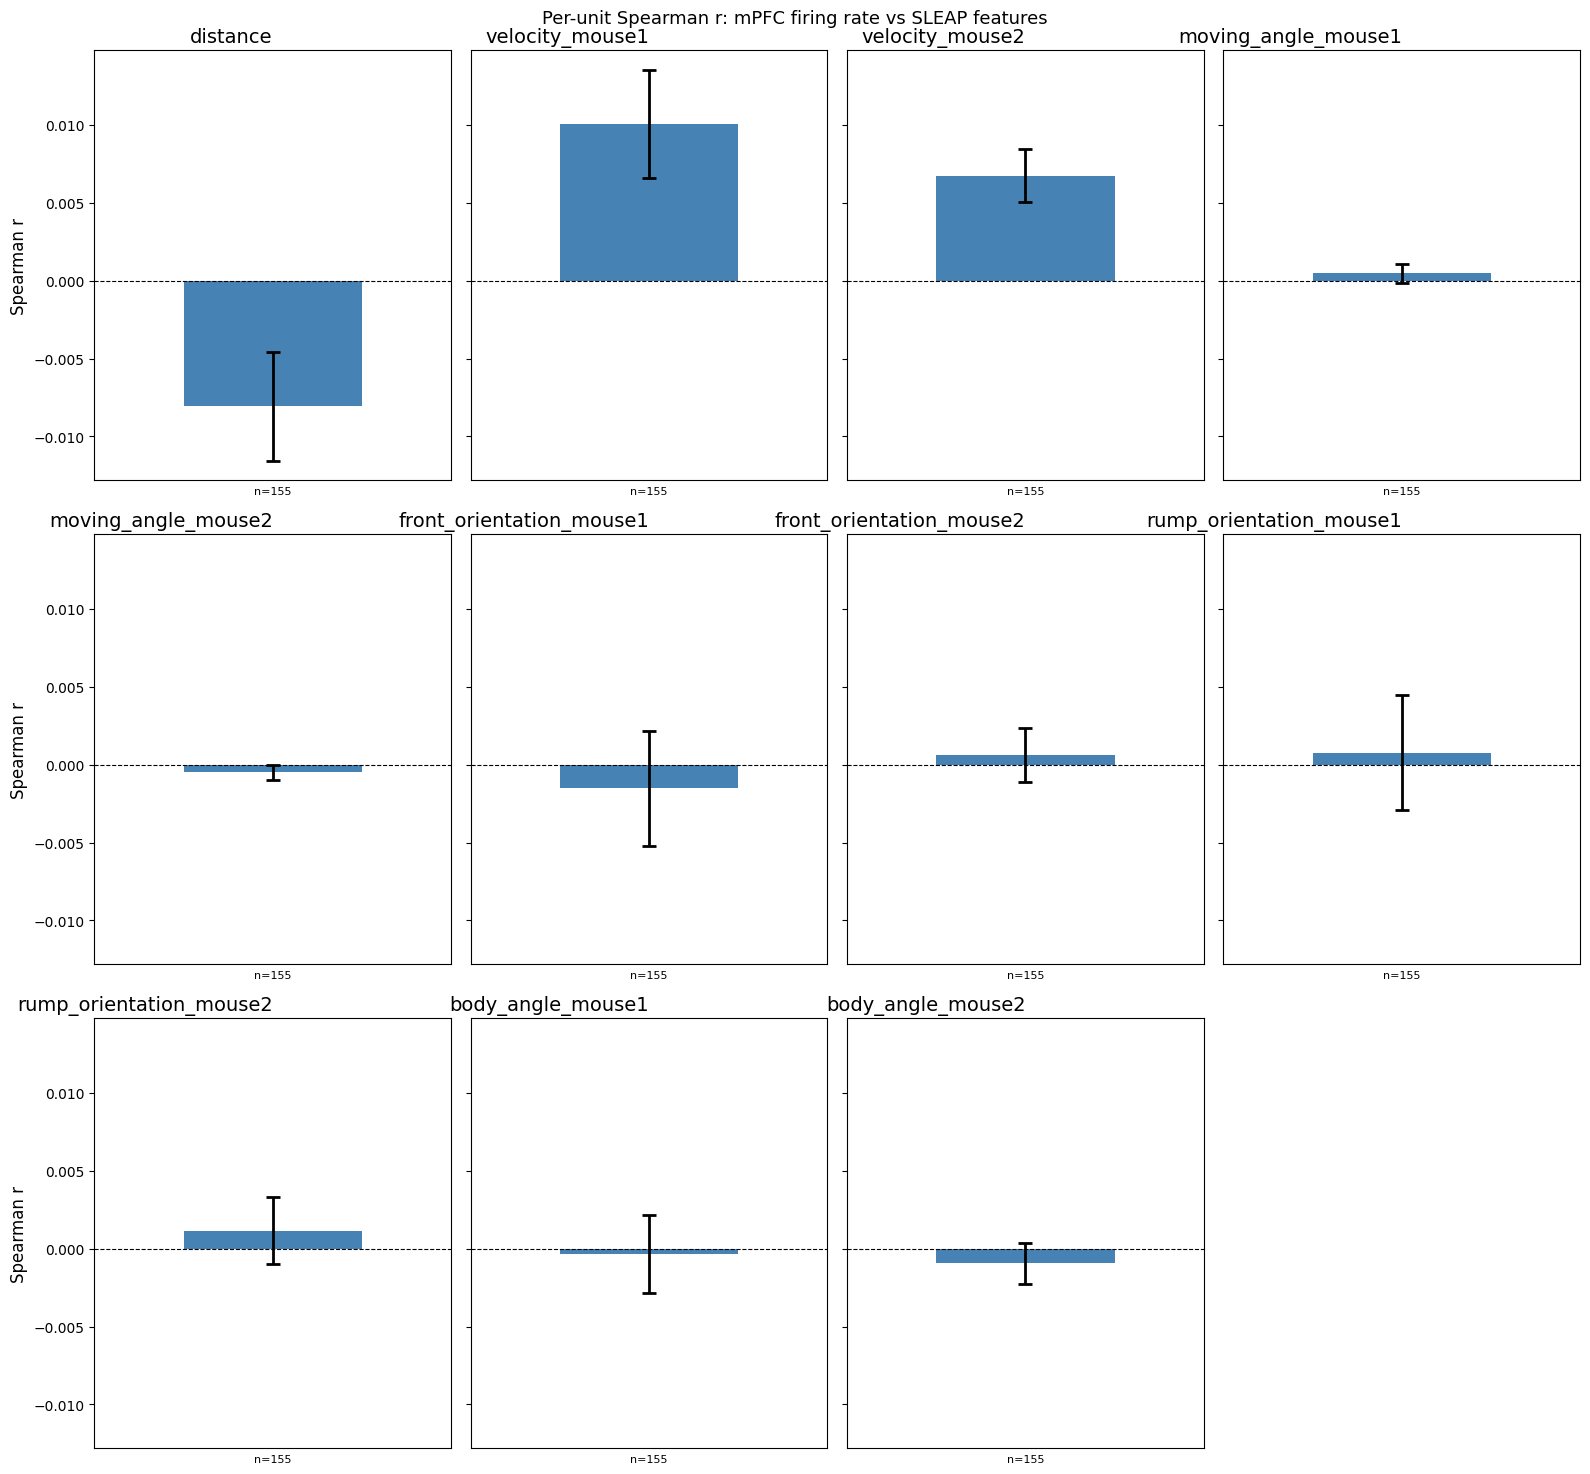

In [16]:
import math
features = unit_corr_df['feature'].unique()
n_features = len(features)

n_cols = min(4, n_features)
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 5 * n_rows), sharey=True)
axes = np.array(axes).flatten()

for ax, feat in zip(axes, features):
    vals = unit_corr_df[unit_corr_df['feature'] == feat]['spearman_r'].values
    mean = np.nanmean(vals)
    sem  = stats.sem(vals, nan_policy='omit')

    ax.bar(0, mean, yerr=sem, capsize=5, color='steelblue', width=0.5,
           error_kw={'elinewidth': 2, 'capthick': 2})
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(feat, fontsize=14, rotation=0, ha='right')
    ax.set_xticks([])
    ax.set_xlim(-0.5, 0.5)
    n = len(vals)
    ax.set_xlabel(f'n={n}', fontsize=8)

for ax in axes[n_features:]:
    ax.set_visible(False)

# Set y-label only on leftmost axes in each row
for row in range(n_rows):
    axes[row * n_cols].set_ylabel('Spearman r', fontsize=12)
fig.suptitle('Per-unit Spearman r: mPFC firing rate vs SLEAP features', fontsize=13)
plt.tight_layout()
plt.show()

## Plot: population Spearman r (n = sessions)

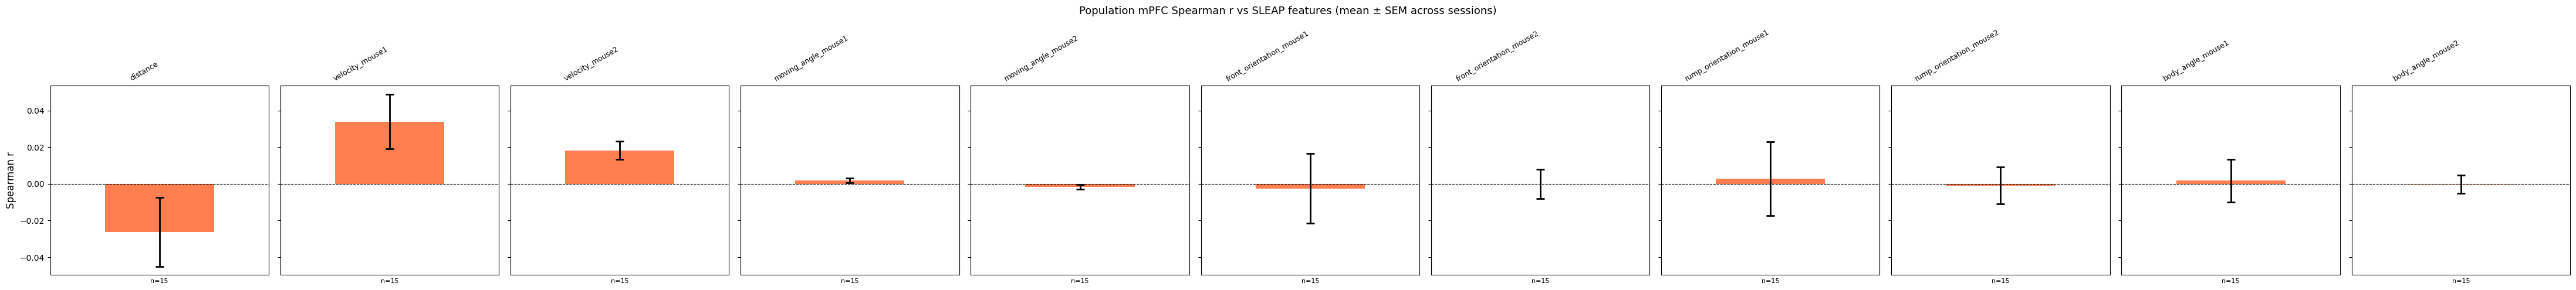

In [17]:
fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 5), sharey=True)

for ax, feat in zip(axes, features):
    vals = pop_corr_df[pop_corr_df['feature'] == feat]['spearman_r'].values
    mean = np.nanmean(vals)
    sem  = stats.sem(vals, nan_policy='omit')

    ax.bar(0, mean, yerr=sem, capsize=5, color='coral', width=0.5,
           error_kw={'elinewidth': 2, 'capthick': 2})
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_title(feat, fontsize=9, rotation=30, ha='right')
    ax.set_xticks([])
    ax.set_xlim(-0.5, 0.5)
    n = len(vals)
    ax.set_xlabel(f'n={n}', fontsize=8)

axes[0].set_ylabel('Spearman r', fontsize=12)
fig.suptitle('Population mPFC Spearman r vs SLEAP features (mean ± SEM across sessions)', fontsize=13)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import KBinsDiscretizer
from tqdm import tqdm

def mi_fast(x, y, n_bins=10):
    """Fast MI using numpy histogram2d — skips all sklearn overhead."""
    hist, _, _ = np.histogram2d(x, y, bins=n_bins)
    hist = hist / hist.sum()
    px = hist.sum(axis=1, keepdims=True)
    py = hist.sum(axis=0, keepdims=True)
    mask = hist > 0
    return float(np.sum(hist[mask] * np.log(hist[mask] / (px * py)[mask])))

def compute_mi_baselined(firing_rate, stimulus, n_bins=10, n_shuffles=100):
    actual_mi = mi_fast(firing_rate, stimulus, n_bins)
    shuffled_mis = np.array([
        mi_fast(firing_rate, np.random.permutation(stimulus), n_bins)
        for _ in range(n_shuffles)
    ])
    return actual_mi - shuffled_mis.mean()

N_SHUFFLES = 100
AGENTS     = ['cagemate', 'novel', 'familiar']

unit_corr_rows = []
pop_corr_rows  = []
unit_mi_rows   = []
pop_mi_rows    = []

for recording in tqdm(spike_collection.recordings, desc='recordings'):
    rec_name = recording.name
    subject  = getattr(recording, 'subject', rec_name)

    if rec_name not in sleap_dicts:
        print(f'No SLEAP data for {rec_name}, skipping')
        continue
    if recording.analyzed_neurons == 0:
        print(f'{rec_name}: 0 analyzed neurons, skipping')
        continue

    spike_time_ms = build_spike_time_axis(recording, TIMEBIN)
    fr_matrix     = np.array([recording.unit_firing_rates[u]
                               for u in recording.unit_firing_rates])
    pop_fr        = np.nanmean(fr_matrix, axis=0)

    for agent, agent_info in sleap_dicts[rec_name].items():
        sleap_time_ms  = agent_info['time_ms']
        sleap_features = agent_info['features_1ms']
        feature_legend = agent_info['feature_legend']

        binned_features = bin_sleap_to_spike(
            sleap_time_ms, sleap_features, spike_time_ms, TIMEBIN)

        valid_mask = (~np.any(np.isnan(binned_features), axis=1)
                      & ~np.isnan(pop_fr))

        if valid_mask.sum() < 10:
            print(f'{rec_name} | {agent}: {valid_mask.sum()} valid timepoints, skipping')
            continue

        # --- per-unit Spearman + MI ---
        for unit_id, fr in recording.unit_firing_rates.items():
            unit_mask = valid_mask & ~np.isnan(fr)
            if unit_mask.sum() < 10:
                continue
            for feat_idx, feat_name in enumerate(feature_legend):
                fr_vals   = fr[unit_mask]
                feat_vals = binned_features[unit_mask, feat_idx]

                r, p = spearmanr(fr_vals, feat_vals)
                unit_corr_rows.append({
                    'subject': subject, 'recording': rec_name, 'agent': agent,
                    'unit_id': unit_id, 'feature': feat_name,
                    'spearman_r': r, 'pval': p,
                })

                mi = compute_mi_baselined(fr_vals, feat_vals, n_shuffles=N_SHUFFLES)
                unit_mi_rows.append({
                    'subject': subject, 'recording': rec_name, 'agent': agent,
                    'unit_id': unit_id, 'feature': feat_name, 'mi': mi,
                })

        # --- population Spearman + MI ---
        for feat_idx, feat_name in enumerate(feature_legend):
            pop_vals  = pop_fr[valid_mask]
            feat_vals = binned_features[valid_mask, feat_idx]

            r, p = spearmanr(pop_vals, feat_vals)
            pop_corr_rows.append({
                'subject': subject, 'recording': rec_name, 'agent': agent,
                'feature': feat_name, 'spearman_r': r, 'pval': p,
            })

            mi = compute_mi_baselined(pop_vals, feat_vals, n_shuffles=N_SHUFFLES)
            pop_mi_rows.append({
                'subject': subject, 'recording': rec_name, 'agent': agent,
                'feature': feat_name, 'mi': mi,
            })

unit_corr_df = pd.DataFrame(unit_corr_rows)
pop_corr_df  = pd.DataFrame(pop_corr_rows)
unit_mi_df   = pd.DataFrame(unit_mi_rows)
pop_mi_df    = pd.DataFrame(pop_mi_rows)

print(f'Unit Spearman:       {len(unit_corr_df)} rows')
print(f'Population Spearman: {len(pop_corr_df)} rows')
print(f'Unit MI (baselined): {len(unit_mi_df)} rows')
print(f'Population MI (baselined): {len(pop_mi_df)} rows')

recordings: 100%|██████████| 15/15 [04:27<00:00, 17.85s/it]

Unit Spearman:       5115 rows
Population Spearman: 495 rows
Unit MI (baselined): 5115 rows
Population MI (baselined): 495 rows


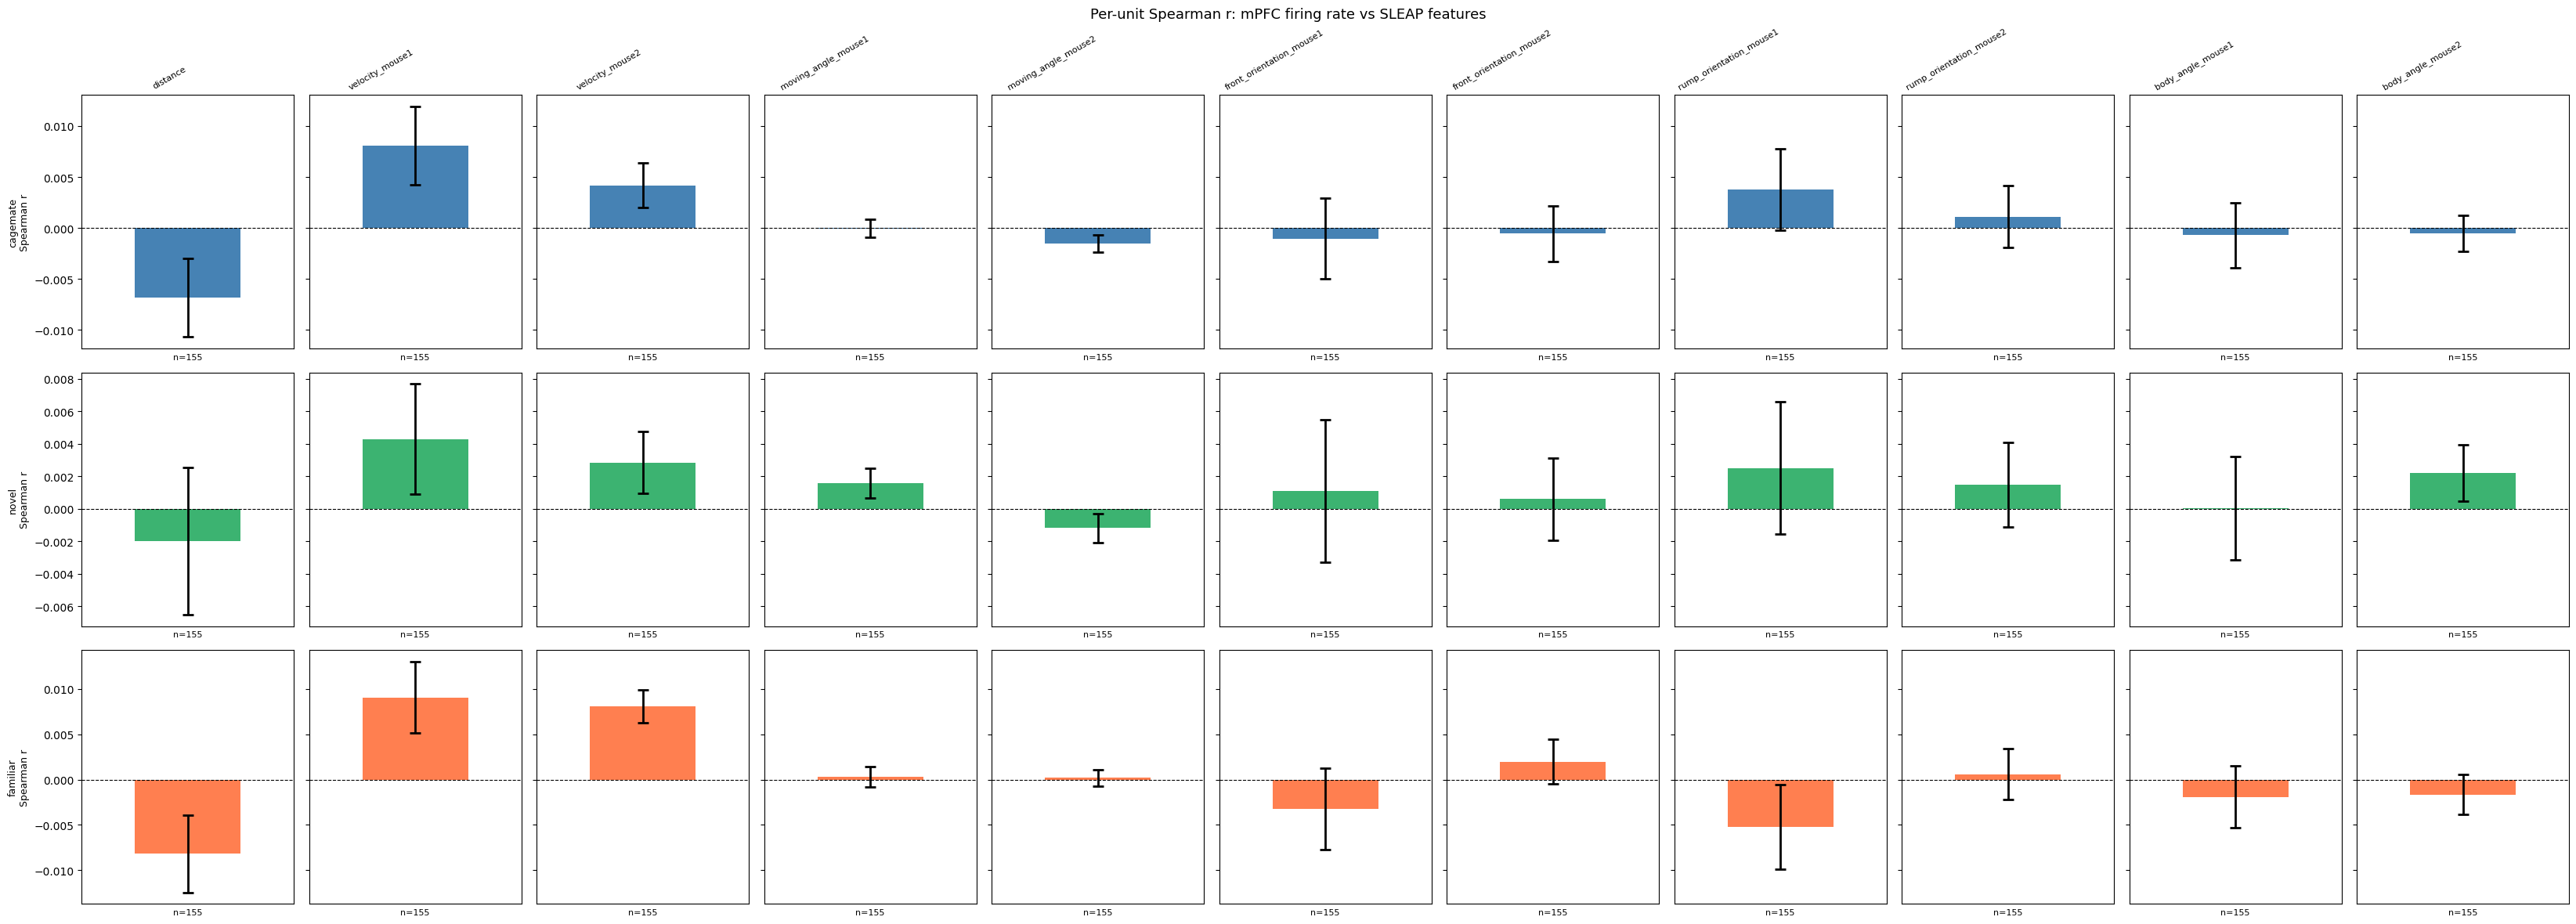

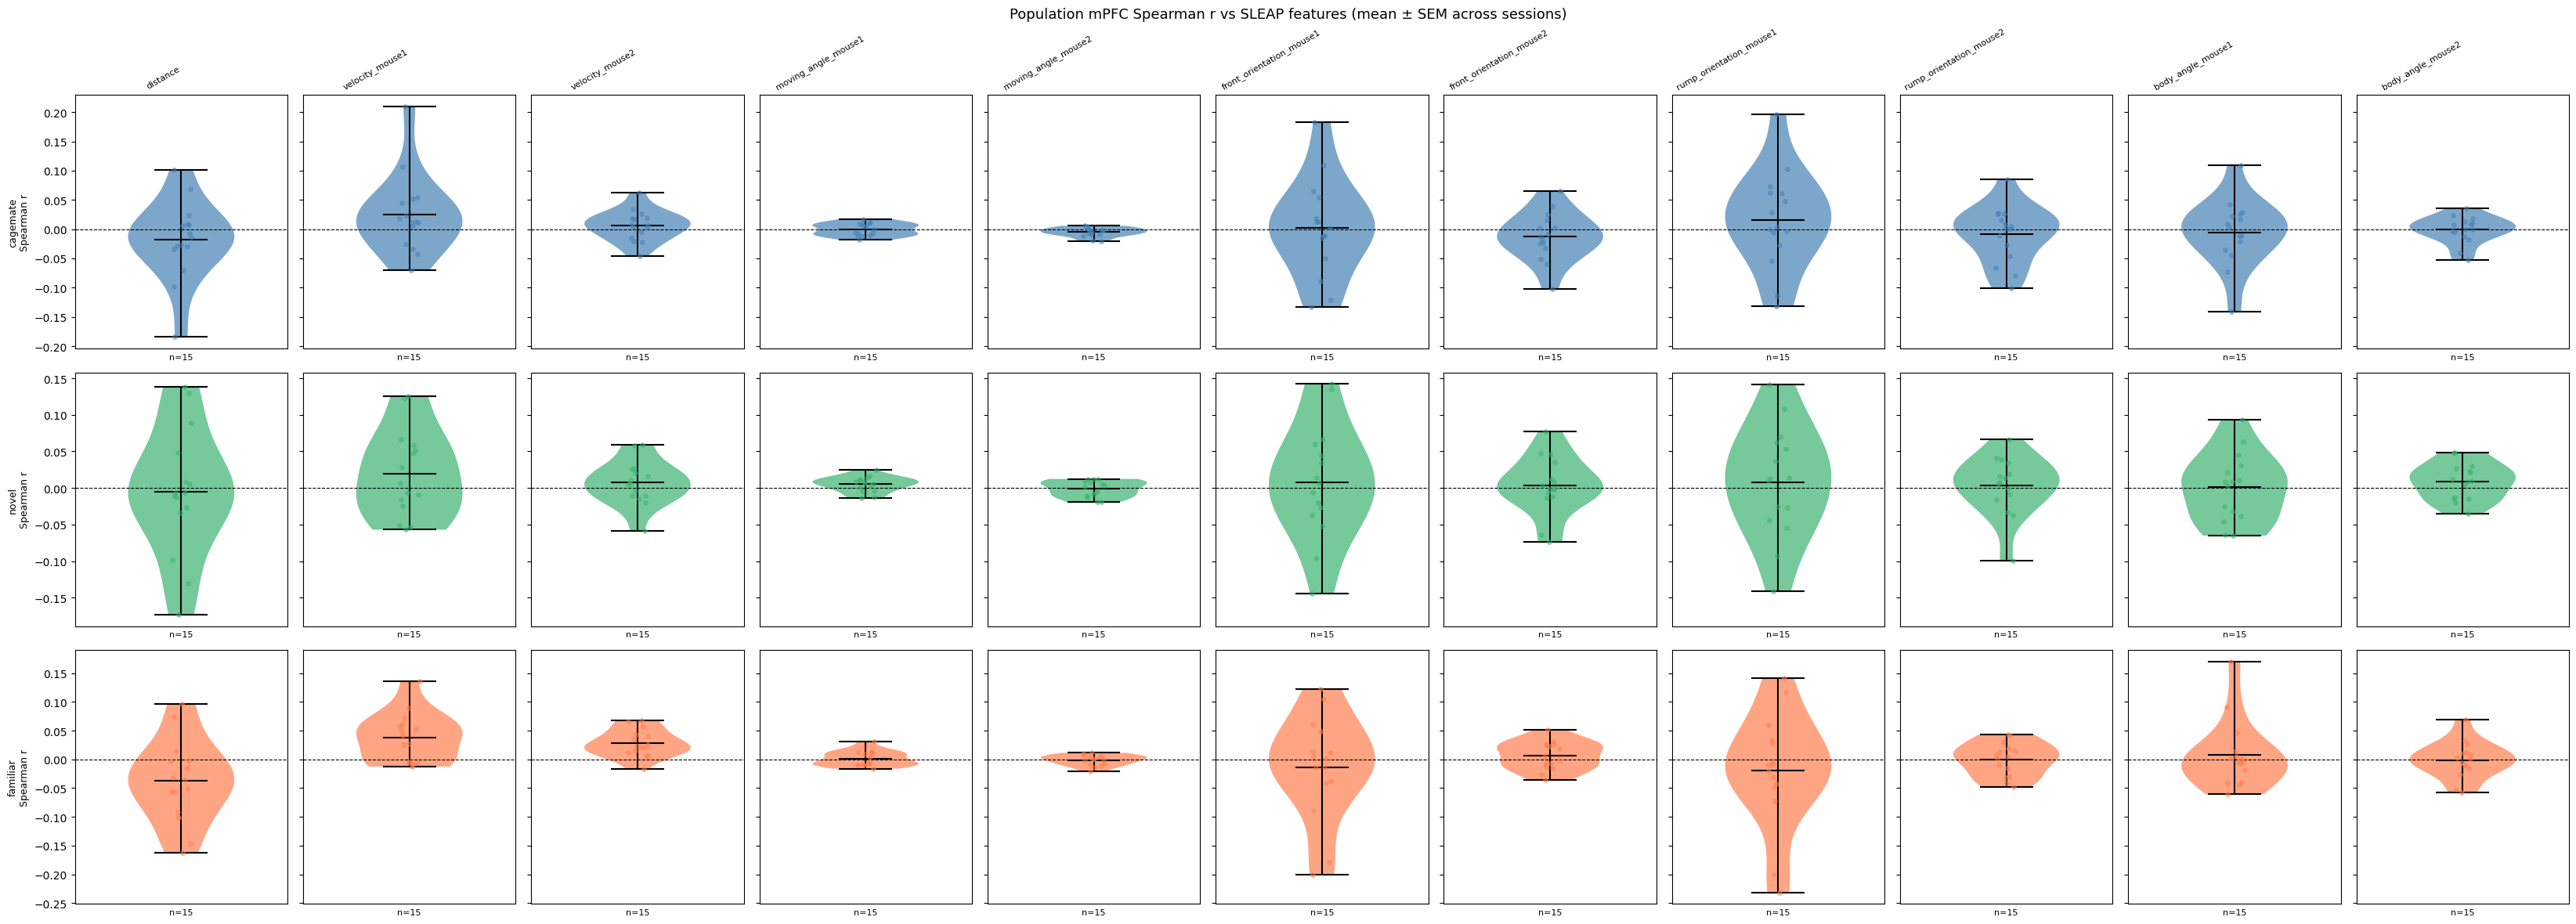

In [19]:
agents     = AGENTS
features   = unit_corr_df['feature'].unique()
n_features = len(features)
n_agents   = len(agents)

agent_colors = {'cagemate': 'steelblue', 'novel': 'mediumseagreen', 'familiar': 'coral'}

fig, axes = plt.subplots(n_agents, n_features,
                        figsize=(3 * n_features, 4 * n_agents),
                        sharey='row', sharex='col')

for row, agent in enumerate(agents):
    agent_df = unit_corr_df[unit_corr_df['agent'] == agent]
    for col, feat in enumerate(features):
        ax   = axes[row, col]
        vals = agent_df[agent_df['feature'] == feat]['spearman_r'].values
        mean = np.nanmean(vals)
        sem  = stats.sem(vals, nan_policy='omit')

        ax.bar(0, mean, yerr=sem, capsize=5,
                color=agent_colors.get(agent, 'gray'), width=0.5,
                error_kw={'elinewidth': 2, 'capthick': 2})
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
        ax.set_xticks([])
        ax.set_xlim(-0.5, 0.5)
        ax.set_xlabel(f'n={len(vals)}', fontsize=8)

        if row == 0:
            ax.set_title(feat, fontsize=8, rotation=30, ha='right')
        if col == 0:
            ax.set_ylabel(f'{agent}\nSpearman r', fontsize=9)

fig.suptitle('Per-unit Spearman r: mPFC firing rate vs SLEAP features', fontsize=13)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(n_agents, n_features,
                        figsize=(3 * n_features, 4 * n_agents),
                        sharey='row', sharex='col')

for row, agent in enumerate(agents):
    agent_df = pop_corr_df[pop_corr_df['agent'] == agent]
    for col, feat in enumerate(features):
        ax   = axes[row, col]
        vals = agent_df[agent_df['feature'] == feat]['spearman_r'].values
        mean = np.nanmean(vals)
        sem  = stats.sem(vals, nan_policy='omit')

        parts = ax.violinplot(vals, positions=[0], showmeans=True, showmedians=False, widths=0.5)

# color the violin body
        color = agent_colors.get(agent, 'gray')
        for pc in parts['bodies']:
            pc.set_facecolor(color)
            pc.set_alpha(0.7)
        parts['cmeans'].set_color('black')
        parts['cbars'].set_color('black')
        parts['cmins'].set_color('black')
        parts['cmaxes'].set_color('black')

        # overlay individual points with jitter
        jitter = np.random.uniform(-0.05, 0.05, size=len(vals))
        ax.scatter(jitter, vals, color=color, alpha=0.5, s=15, zorder=3)
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
        ax.set_xticks([])
        ax.set_xlim(-0.5, 0.5)
        ax.set_xlabel(f'n={len(vals)}', fontsize=8)

        if row == 0:
            ax.set_title(feat, fontsize=8, rotation=30, ha='right')
        if col == 0:
            ax.set_ylabel(f'{agent}\nSpearman r', fontsize=9)

fig.suptitle('Population mPFC Spearman r vs SLEAP features (mean ± SEM across sessions)',
            fontsize=13)
plt.tight_layout()
plt.show()

## MI (shuffle-baselined): per-unit bar

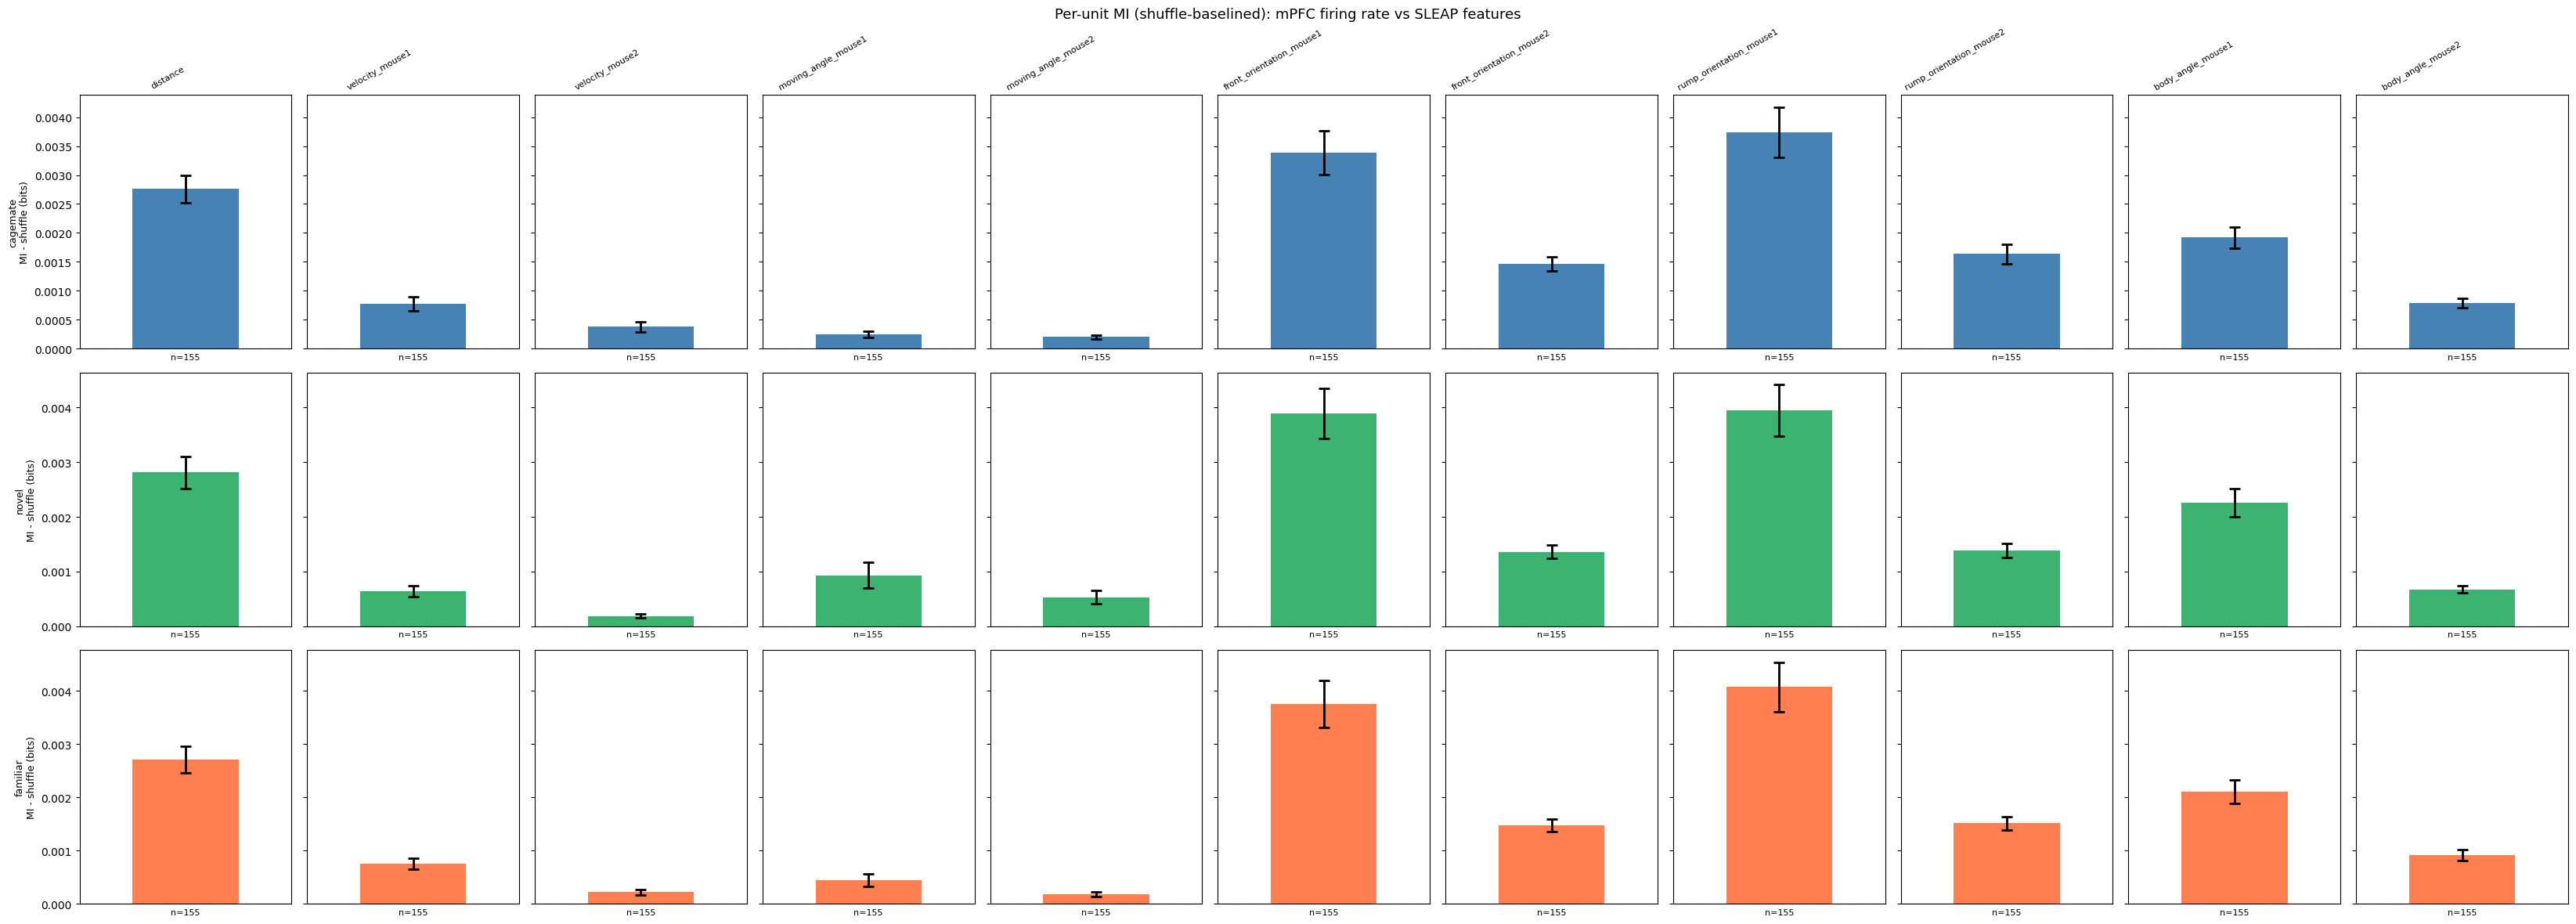

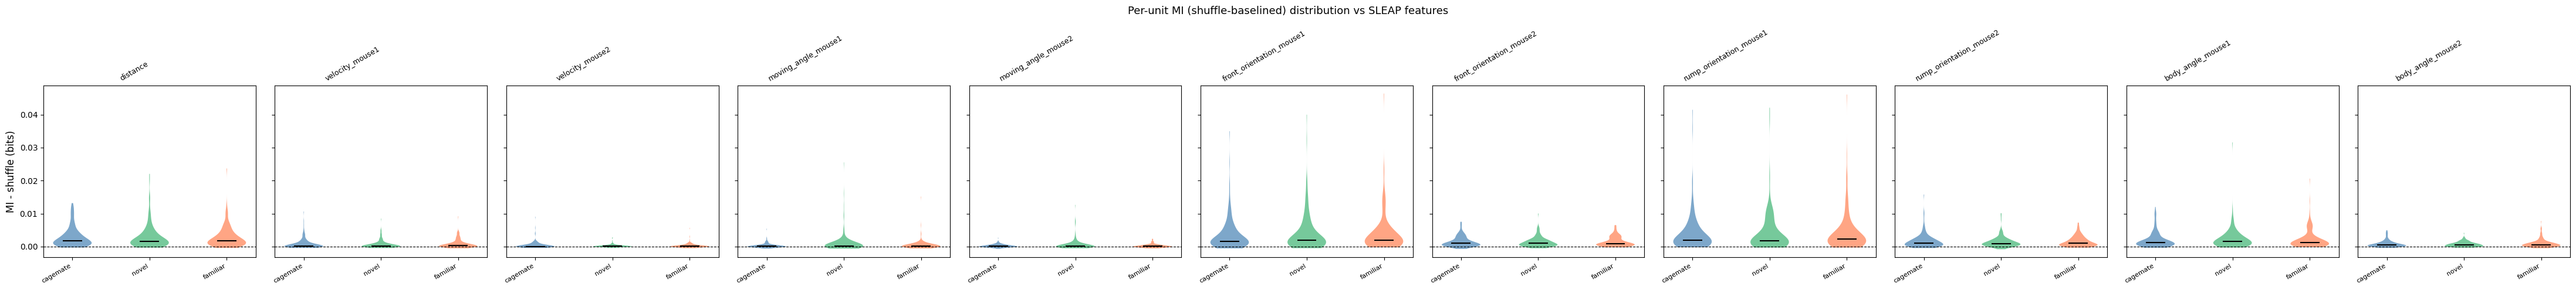

In [20]:
## Per-unit MI bar
fig, axes = plt.subplots(n_agents, n_features,
                         figsize=(3 * n_features, 4 * n_agents),
                         sharey='row', sharex='col')

for row, agent in enumerate(AGENTS):
    agent_df = unit_mi_df[unit_mi_df['agent'] == agent]
    for col, feat in enumerate(features):
        ax   = axes[row, col]
        vals = agent_df[agent_df['feature'] == feat]['mi'].values
        mean = np.nanmean(vals)
        sem  = stats.sem(vals, nan_policy='omit')

        ax.bar(0, mean, yerr=sem, capsize=5,
               color=agent_colors.get(agent, 'gray'), width=0.5,
               error_kw={'elinewidth': 2, 'capthick': 2})
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
        ax.set_xticks([])
        ax.set_xlim(-0.5, 0.5)
        ax.set_xlabel(f'n={len(vals)}', fontsize=8)

        if row == 0:
            ax.set_title(feat, fontsize=8, rotation=30, ha='right')
        if col == 0:
            ax.set_ylabel(f'{agent}\nMI - shuffle (bits)', fontsize=9)

fig.suptitle('Per-unit MI (shuffle-baselined): mPFC firing rate vs SLEAP features', fontsize=13)
plt.tight_layout()
plt.show()

## Per-unit MI violin
fig, axes = plt.subplots(1, n_features,
                         figsize=(4 * n_features, 5), sharey=True)

for col, feat in enumerate(features):
    ax      = axes[col]
    feat_df = unit_mi_df[unit_mi_df['feature'] == feat]
    data    = [feat_df[feat_df['agent'] == ag]['mi'].values for ag in AGENTS]
    colors  = [agent_colors[ag] for ag in AGENTS]

    parts = ax.violinplot(data, positions=range(n_agents),
                          showmedians=True, showextrema=False)
    for body, color in zip(parts['bodies'], colors):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    parts['cmedians'].set_color('black')

    ax.set_xticks(range(n_agents))
    ax.set_xticklabels(AGENTS, rotation=30, ha='right', fontsize=8)
    ax.set_title(feat, fontsize=9, rotation=30, ha='right')
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

axes[0].set_ylabel('MI - shuffle (bits)', fontsize=12)
fig.suptitle('Per-unit MI (shuffle-baselined) distribution vs SLEAP features', fontsize=13)
plt.tight_layout()
plt.show()

## MI (shuffle-baselined): population bar + violin

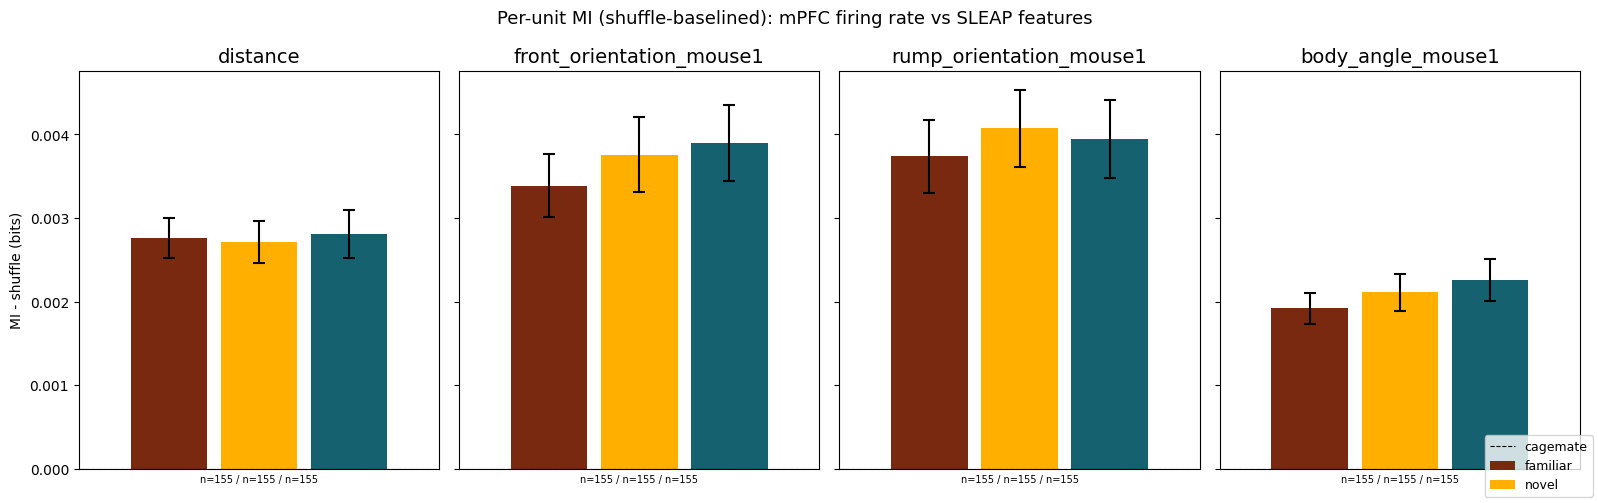

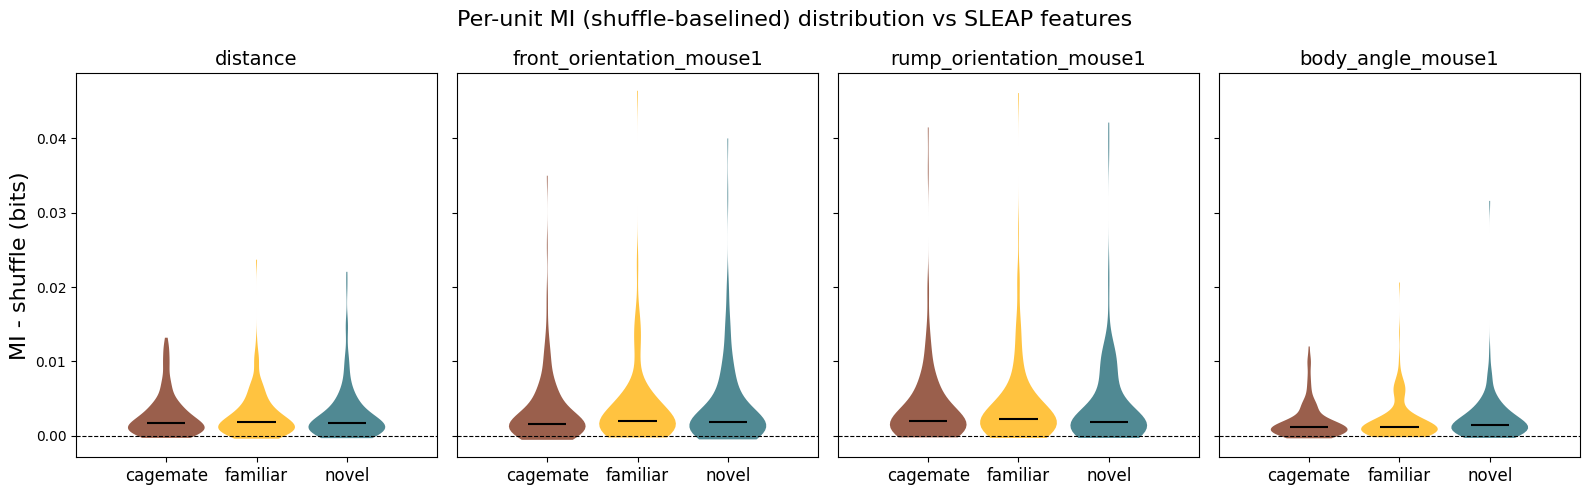

In [21]:
def plot_mi_bars_and_violins(mi_df, agent_colors, features, AGENTS, title_prefix='Population'):
    n_features = len(features)
    n_agents   = len(AGENTS)
    n_cols     = min(4, n_features)
    n_rows     = math.ceil(n_features / n_cols)

    bar_w   = 0.25
    gap     = 0.2
    positions = np.array([i * bar_w for i in range(n_agents)])
    positions = positions - positions.mean()  # center the group

    # ── BAR PLOT ──────────────────────────────────────────────────────────────
    fig_bar, axes_bar = plt.subplots(n_rows, n_cols,
                                      figsize=(4 * n_cols, 5 * n_rows),
                                      sharey=True)
    axes_bar = np.array(axes_bar).flatten()

    for ax, feat in zip(axes_bar, features):
        for i, agent in enumerate(AGENTS):
            vals = mi_df[(mi_df['feature'] == feat) & (mi_df['agent'] == agent)]['mi'].values
            mean = np.nanmean(vals)
            sem  = stats.sem(vals, nan_policy='omit')

            ax.bar(positions[i], mean, yerr=sem, capsize=4,
                   color=agent_colors.get(agent, 'gray'),
                   width=bar_w * 0.85,
                   label=agent if feat == features[0] else None,
                   error_kw={'elinewidth': 1.5, 'capthick': 1.5})

        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
        ax.set_title(feat, fontsize=14, rotation=0)
        ax.set_xticks([])
        ax.set_xlim(positions[0] - bar_w, positions[-1] + bar_w)
        ns = [len(mi_df[(mi_df['feature'] == feat) & (mi_df['agent'] == ag)]) for ag in AGENTS]
        ax.set_xlabel(' / '.join([f'n={n}' for n in ns]), fontsize=7)

    for ax in axes_bar[n_features:]:
        ax.set_visible(False)
    for row in range(n_rows):
        axes_bar[row * n_cols].set_ylabel('MI - shuffle (bits)', fontsize=10)

    fig_bar.suptitle(f'{title_prefix} MI (shuffle-baselined): mPFC firing rate vs SLEAP features',
                     fontsize=13)
    fig_bar.legend(AGENTS, loc='lower right', fontsize=9, framealpha=0.8)
    plt.tight_layout()
    plt.show()

    # ── VIOLIN PLOT ───────────────────────────────────────────────────────────
    fig_vln, axes_vln = plt.subplots(n_rows, n_cols,
                                      figsize=(4 * n_cols, 5 * n_rows),
                                      sharey=True)
    axes_vln = np.array(axes_vln).flatten()

    for ax, feat in zip(axes_vln, features):
        data   = [mi_df[(mi_df['feature'] == feat) & (mi_df['agent'] == ag)]['mi'].values
                  for ag in AGENTS]
        parts  = ax.violinplot(data, positions=positions,
                               widths=bar_w * 0.85,
                               showmedians=True, showextrema=False)
        for body, agent in zip(parts['bodies'], AGENTS):
            body.set_facecolor(agent_colors.get(agent, 'gray'))
            body.set_alpha(0.75)
        parts['cmedians'].set_color('black')
        parts['cmedians'].set_linewidth(1.5)

        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
        ax.set_title(feat, fontsize=14, rotation=0)
        ax.set_xticks(positions)
        ax.set_xticklabels(AGENTS, fontsize=12, rotation=0)
        ax.set_xlim(positions[0] - bar_w, positions[-1] + bar_w)

    for ax in axes_vln[n_features:]:
        ax.set_visible(False)
    for row in range(n_rows):
        axes_vln[row * n_cols].set_ylabel('MI - shuffle (bits)', fontsize=16)

    fig_vln.suptitle(f'{title_prefix} MI (shuffle-baselined) distribution vs SLEAP features',
                     fontsize=16)
    plt.tight_layout()
    plt.show()

agent_colors = {
    "cagemate": "#792910",
    "familiar": "#FFAF00",
    "novel":    "#15616F"
}
plot_mi_bars_and_violins(unit_mi_df, agent_colors, 
                         features = ['distance', 'front_orientation_mouse1', 'rump_orientation_mouse1', 'body_angle_mouse1'],
                         AGENTS =['cagemate', 'familiar', 'novel'], title_prefix='Per-unit')

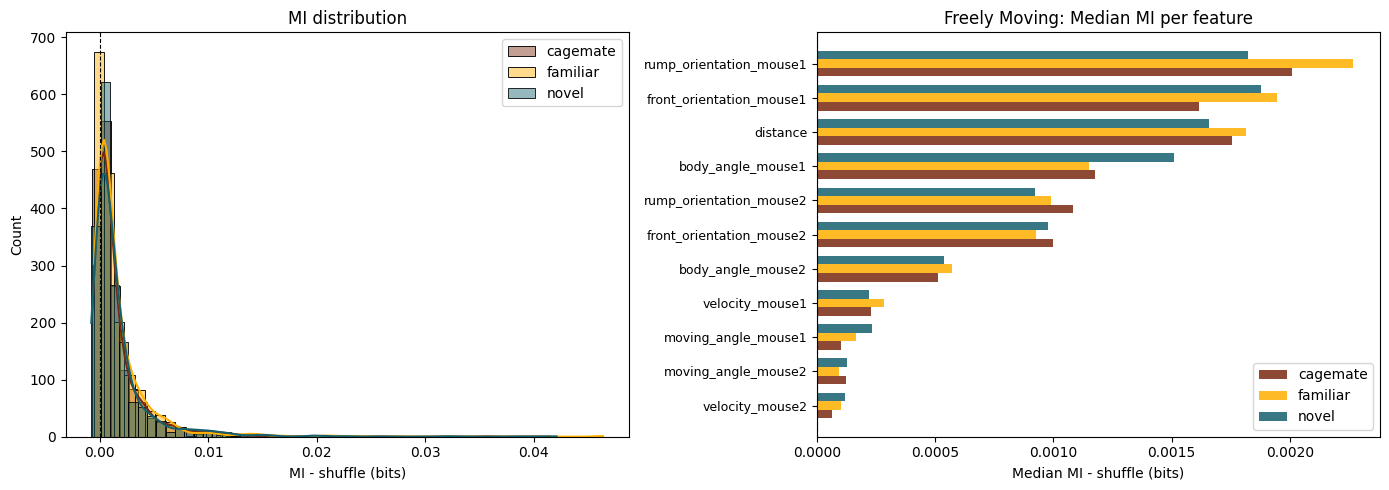


cagemate:
  75th percentile MI: 0.0018
  90th percentile MI: 0.0042
  95th percentile MI: 0.0065
  99th percentile MI: 0.0121

familiar:
  75th percentile MI: 0.0019
  90th percentile MI: 0.0042
  95th percentile MI: 0.0063
  99th percentile MI: 0.0143

novel:
  75th percentile MI: 0.0019
  90th percentile MI: 0.0043
  95th percentile MI: 0.0075
  99th percentile MI: 0.0152


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

agent_colors = {
    "cagemate": "#792910",
    "familiar": "#FFAF00",
    "novel":    "#15616F"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── overlapping distributions per agent ──────────────────────────────────────
for agent, color in agent_colors.items():
    vals = unit_mi_df[unit_mi_df['agent'] == agent]['mi']
    sns.histplot(vals, bins=50, ax=axes[0],
                 color=color, alpha=0.45, label=agent, kde=True)

axes[0].set_title('MI distribution')
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('MI - shuffle (bits)')
axes[0].legend()

# ── paired horizontal bars per feature × agent ───────────────────────────────
agents = list(agent_colors.keys())
n_agents = len(agents)
bar_h = 0.25
# sort features by mean median across agents
feature_order = (unit_mi_df.groupby('feature')['mi']
                 .median()
                 .sort_values()
                 .index)
y = np.arange(len(feature_order))

for i, agent in enumerate(agents):
    medians = (unit_mi_df[unit_mi_df['agent'] == agent]
               .groupby('feature')['mi']
               .median()
               .reindex(feature_order))
    offset = (i - (n_agents - 1) / 2) * bar_h
    axes[1].barh(y + offset, medians, height=bar_h,
                 color=agent_colors[agent], alpha=0.85, label=agent)

axes[1].set_yticks(y)
axes[1].set_yticklabels(feature_order, fontsize=9)
axes[1].set_title('Freely Moving: Median MI per feature')
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Median MI - shuffle (bits)')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── percentiles per agent ─────────────────────────────────────────────────────
for agent in agents:
    print(f"\n{agent}:")
    vals = unit_mi_df[unit_mi_df['agent'] == agent]['mi'].values
    for pct in [75, 90, 95, 99]:
        print(f"  {pct}th percentile MI: {np.percentile(vals, pct):.4f}")

## MI (shuffle-baselined): Venn — units above shuffle per agent

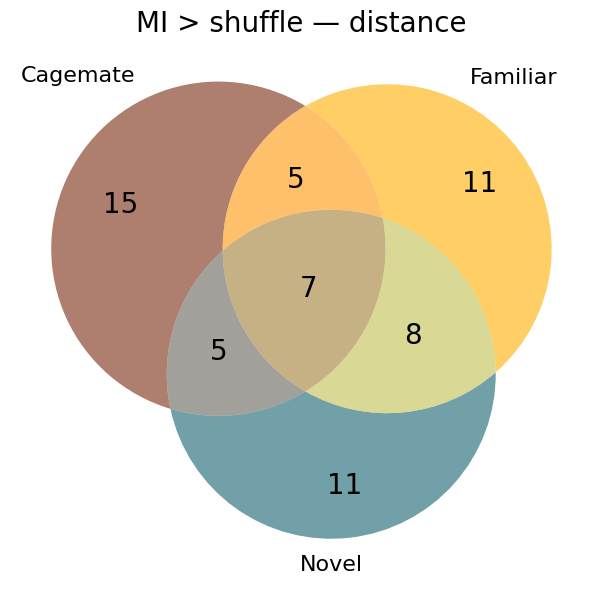

Feature: distance  |  threshold: MI > 0 (above shuffle)
  Cagemate : 32 units
  Familiar : 31 units
  Novel    : 31 units
  All three: 7


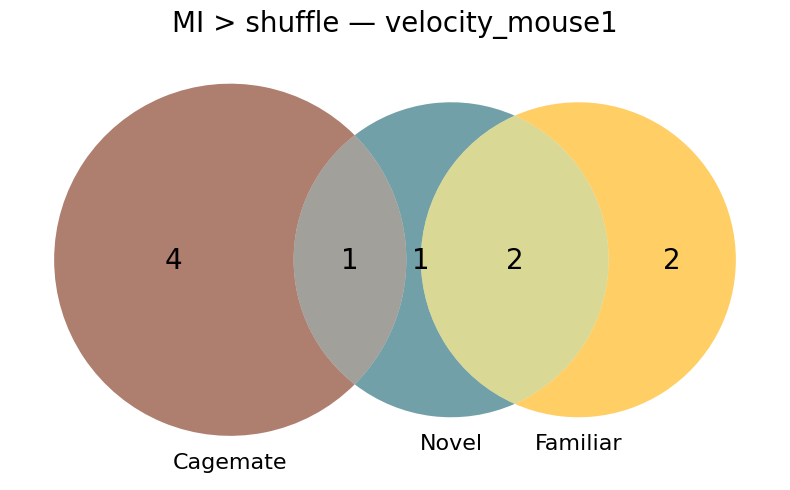

Feature: velocity_mouse1  |  threshold: MI > 0 (above shuffle)
  Cagemate : 5 units
  Familiar : 4 units
  Novel    : 4 units
  All three: 0


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\matplotlib_venn\layout\venn3\pairwise.py:111: UserWarning: Circle C has zero area.
  warnings.warn("Circle C has zero area.")


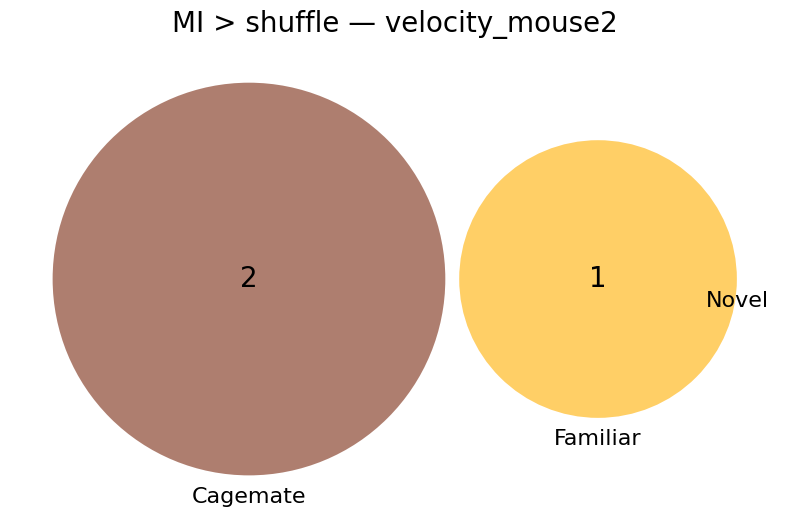

Feature: velocity_mouse2  |  threshold: MI > 0 (above shuffle)
  Cagemate : 2 units
  Familiar : 1 units
  Novel    : 0 units
  All three: 0


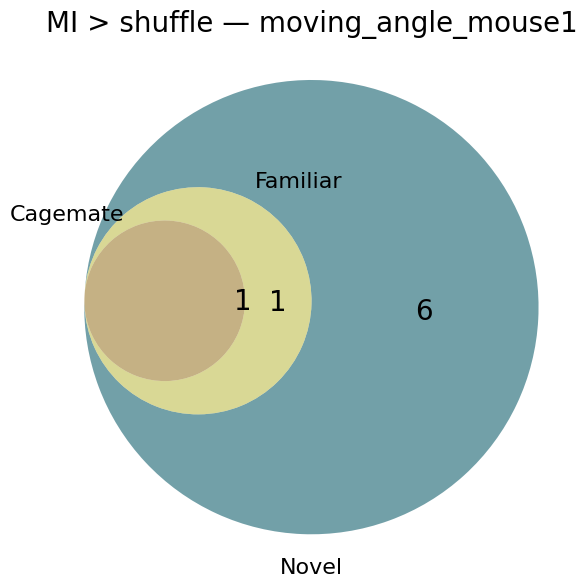

Feature: moving_angle_mouse1  |  threshold: MI > 0 (above shuffle)
  Cagemate : 1 units
  Familiar : 2 units
  Novel    : 8 units
  All three: 1


c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\matplotlib_venn\layout\venn3\pairwise.py:103: UserWarning: Circle A has zero area.
  warnings.warn("Circle A has zero area.")
c:\Users\megha\anaconda3\envs\ephys_env\lib\site-packages\matplotlib_venn\layout\venn3\pairwise.py:107: UserWarning: Circle B has zero area.
  warnings.warn("Circle B has zero area.")


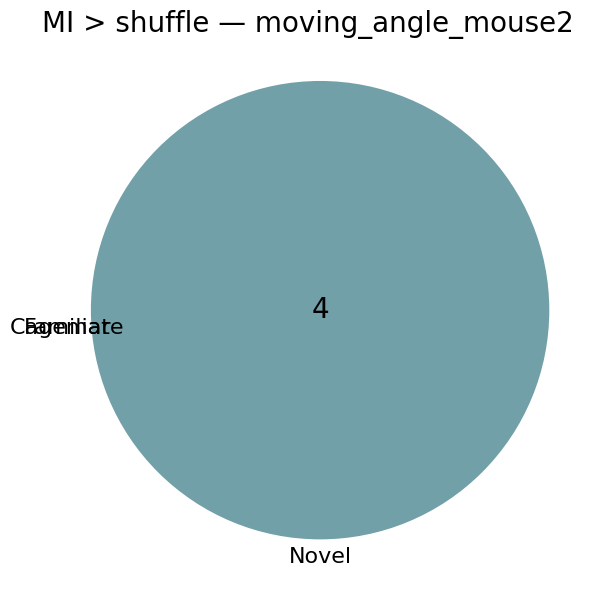

Feature: moving_angle_mouse2  |  threshold: MI > 0 (above shuffle)
  Cagemate : 0 units
  Familiar : 0 units
  Novel    : 4 units
  All three: 0


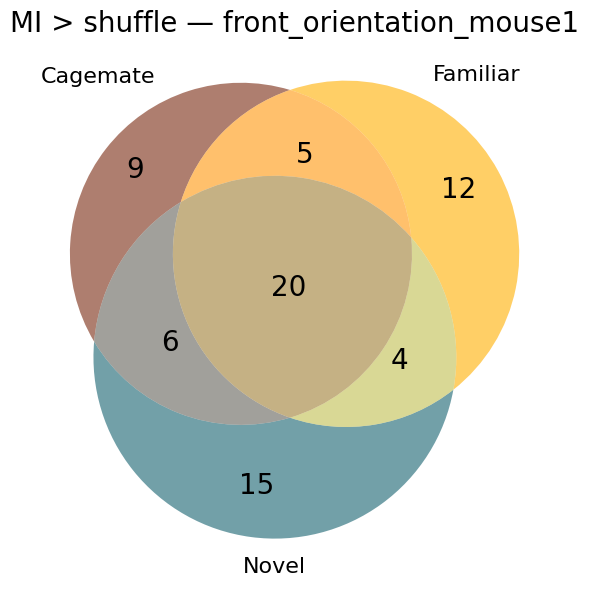

Feature: front_orientation_mouse1  |  threshold: MI > 0 (above shuffle)
  Cagemate : 40 units
  Familiar : 41 units
  Novel    : 45 units
  All three: 20


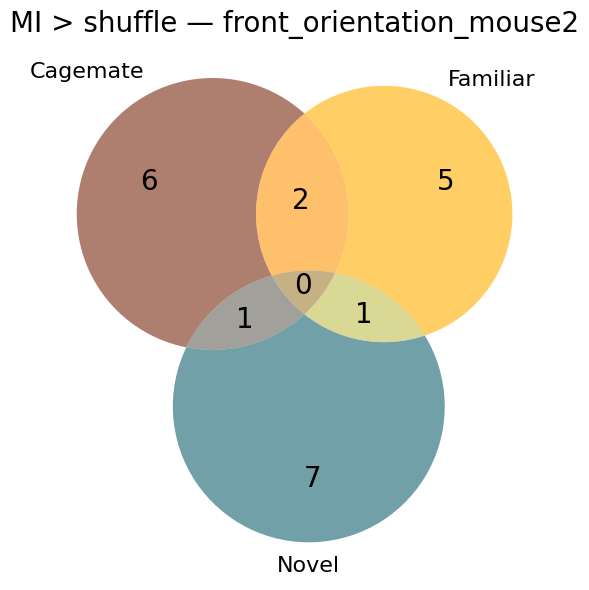

Feature: front_orientation_mouse2  |  threshold: MI > 0 (above shuffle)
  Cagemate : 9 units
  Familiar : 8 units
  Novel    : 9 units
  All three: 0


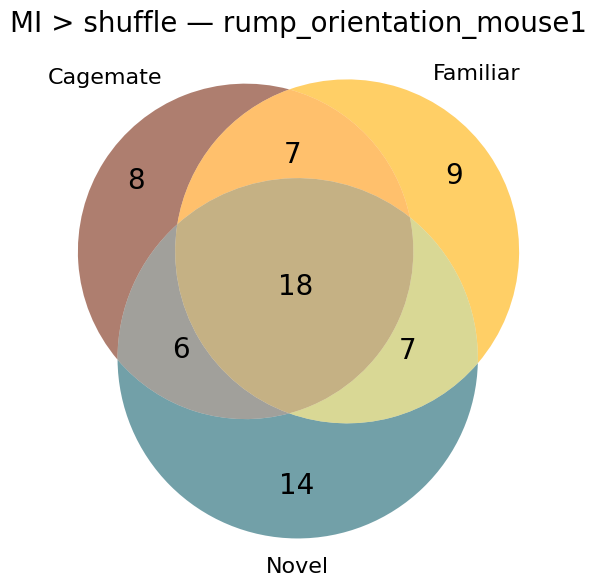

Feature: rump_orientation_mouse1  |  threshold: MI > 0 (above shuffle)
  Cagemate : 39 units
  Familiar : 41 units
  Novel    : 45 units
  All three: 18


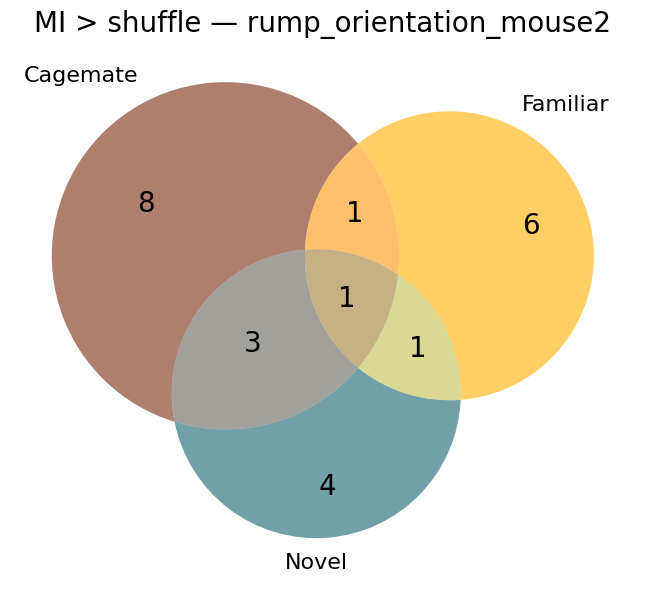

Feature: rump_orientation_mouse2  |  threshold: MI > 0 (above shuffle)
  Cagemate : 13 units
  Familiar : 9 units
  Novel    : 9 units
  All three: 1


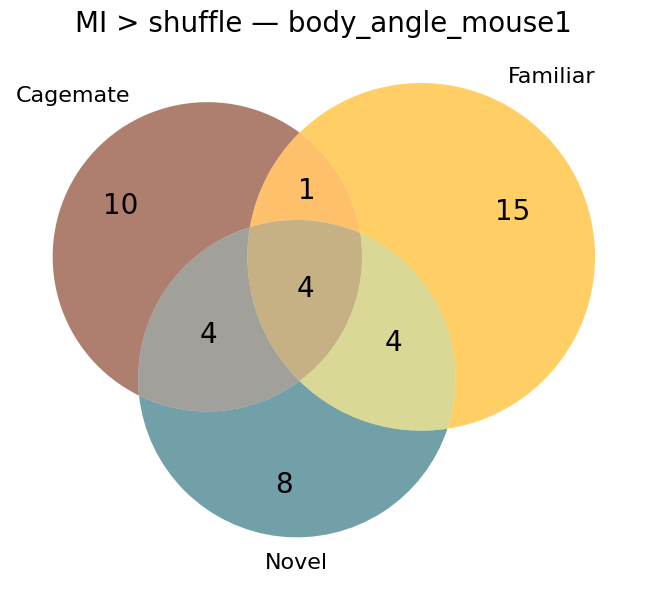

Feature: body_angle_mouse1  |  threshold: MI > 0 (above shuffle)
  Cagemate : 19 units
  Familiar : 24 units
  Novel    : 20 units
  All three: 4


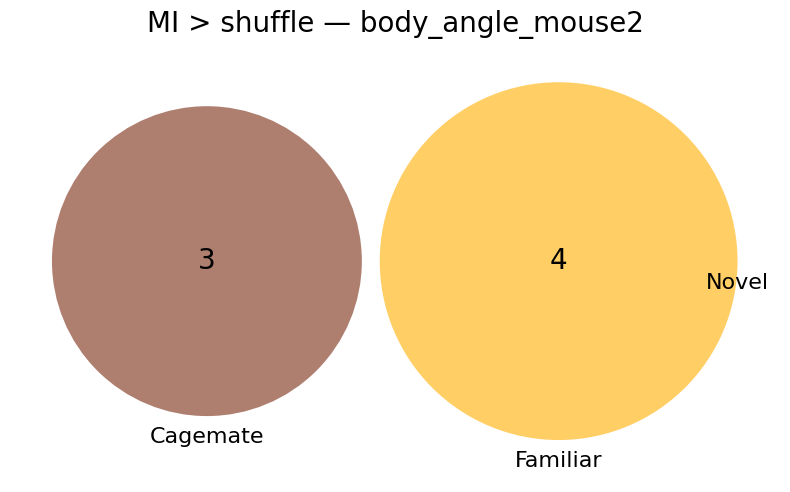

Feature: body_angle_mouse2  |  threshold: MI > 0 (above shuffle)
  Cagemate : 3 units
  Familiar : 4 units
  Novel    : 0 units
  All three: 0


In [23]:
## MI Venn — units with positive baselined MI per agent
from matplotlib_venn import venn3

def plot_mi_venn(unit_mi_df, feature, agent_colors,
                 agent_long='cagemate', agent_short='familiar', agent_novel='novel',
                 title=None):
    df = unit_mi_df[unit_mi_df['feature'] == feature]

    def informative_units(agent):
        mask = (df['agent'] == agent) & (df['mi'] > 0.0043)
        return set(zip(df.loc[mask, 'recording'], df.loc[mask, 'unit_id']))

    set_c = informative_units(agent_long)
    set_f = informative_units(agent_short)
    set_n = informative_units(agent_novel)

    plt.figure(figsize=(8, 6))
    v = venn3([set_c, set_f, set_n],
              set_labels=('Cagemate', 'Familiar', 'Novel'),
              set_colors=(agent_colors[agent_long],
                          agent_colors[agent_short],
                          agent_colors[agent_novel]),
              alpha=0.6)
    for text in (v.set_labels or []):
        if text: text.set_fontsize(16)
    for text in (v.subset_labels or []):
        if text: text.set_fontsize(20)
    plt.title(title or feature, fontsize=20)
    plt.tight_layout()
    plt.show()
    print(f"Feature: {feature}  |  threshold: MI > 0 (above shuffle)")
    print(f"  Cagemate : {len(set_c)} units")
    print(f"  Familiar : {len(set_f)} units")
    print(f"  Novel    : {len(set_n)} units")
    print(f"  All three: {len(set_c & set_f & set_n)}")

for feat in unit_mi_df['feature'].unique():
    plot_mi_venn(unit_mi_df, feat, agent_colors, title=f'MI > shuffle — {feat}')

In [24]:
from matplotlib_venn import venn3

def plot_tuning_venn(unit_corr_df, feature, threshold,
                     agent_long, agent_short, agent_novel,
                     title=None):
    """
    Venn diagram of units tuned to a given feature across three agents.

    Parameters
    ----------
    unit_corr_df : DataFrame with columns: unit_id, feature, spearman_r, agent
    feature      : str   — value in the 'feature' column to subset on
    threshold    : float — units with |spearman_r| >= threshold are tuned
    agent_long   : str   — agent column value for long-term agent
    agent_short  : str   — agent column value for short-term agent
    agent_novel  : str   — agent column value for novel agent
    title        : str   — plot title (defaults to feature name)
    """
    df = unit_corr_df[unit_corr_df['feature'] == feature]

    def tuned_units(agent):
        mask = (df['agent'] == agent) & (df['spearman_r'].abs() >= threshold)
        return set(df.loc[mask, 'unit_id'])

    set1 = tuned_units(agent_long)
    set2 = tuned_units(agent_short)
    set3 = tuned_units(agent_novel)

    plt.figure(figsize=(8, 6))
    venn = venn3([set1, set2, set3], ('Long-term', 'Short-term', 'Novel'))

    patch_colors = {
        '100': '#792910',
        '010': '#FFAF00',
        '001': '#15616F',
        '101': '#474640',
    }
    for patch_id, color in patch_colors.items():
        patch = venn.get_patch_by_id(patch_id)
        if patch:
            patch.set_color(color)
            patch.set_alpha(0.7)

    for text in venn.set_labels:
        if text:
            text.set_fontsize(20)
    for text in venn.subset_labels:
        if text:
            text.set_fontsize(28)

    plt.title(title or feature, fontsize=24)
    plt.tight_layout()
    plt.show()

    print(f"Feature: {feature}  |  threshold: |r| >= {threshold}")
    print(f"  Long-term  : {len(set1)} tuned units")
    print(f"  Short-term : {len(set2)} tuned units")
    print(f"  Novel      : {len(set3)} tuned units")
    print(f"  All three  : {len(set1 & set2 & set3)}")

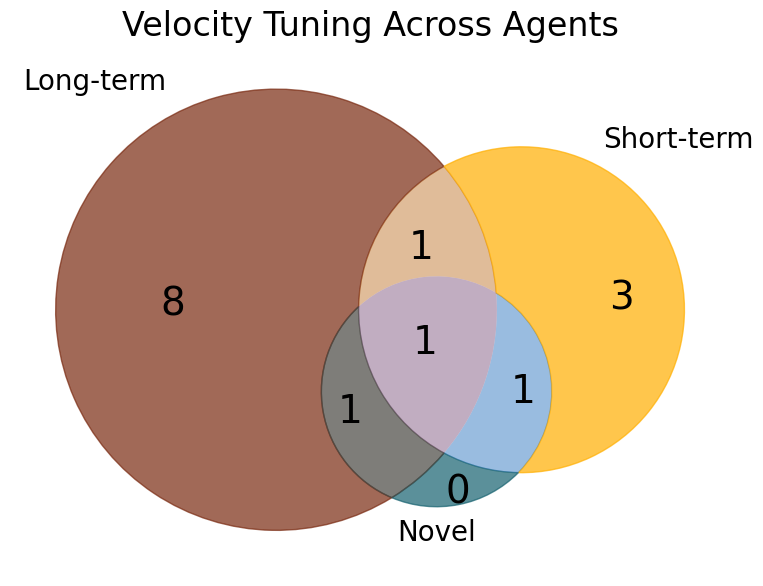

Feature: velocity_mouse1  |  threshold: |r| >= 0.1
  Long-term  : 11 tuned units
  Short-term : 6 tuned units
  Novel      : 3 tuned units
  All three  : 1


In [25]:
plot_tuning_venn(
    unit_corr_df,
    feature   = 'velocity_mouse1',
    threshold = 0.1,
    agent_long  = 'cagemate',    # whatever your actual column values are
    agent_short = 'familiar',
    agent_novel = 'novel',
    title = 'Velocity Tuning Across Agents'
)

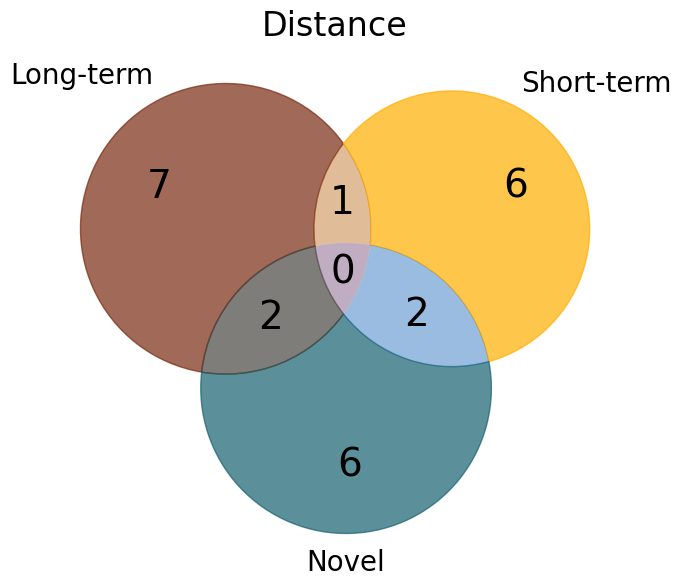

Feature: distance  |  threshold: |r| >= 0.1
  Long-term  : 10 tuned units
  Short-term : 9 tuned units
  Novel      : 10 tuned units
  All three  : 0


In [26]:
plot_tuning_venn(
    unit_corr_df,
    feature   = 'distance',
    threshold = 0.1,
    agent_long  = 'cagemate',    # whatever your actual column values are
    agent_short = 'familiar',
    agent_novel = 'novel',
    title = 'Distance'
)

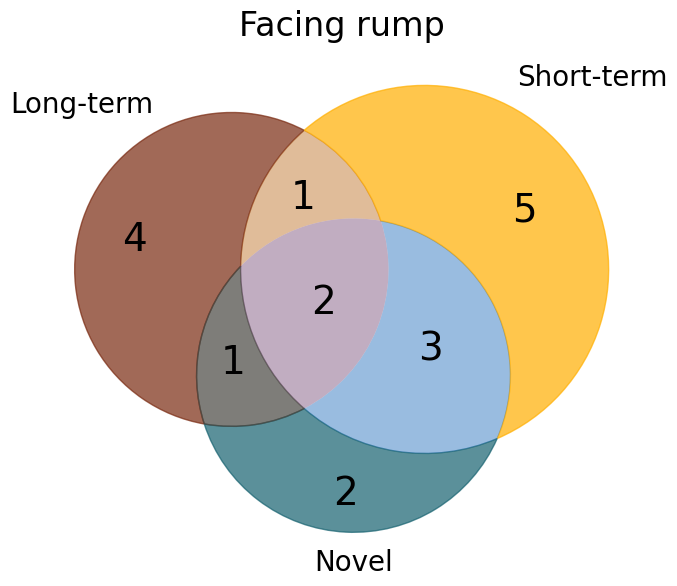

Feature: rump_orientation_mouse1  |  threshold: |r| >= 0.1
  Long-term  : 8 tuned units
  Short-term : 11 tuned units
  Novel      : 8 tuned units
  All three  : 2


In [27]:
plot_tuning_venn(
    unit_corr_df,
    feature   = 'rump_orientation_mouse1',
    threshold = 0.1,
    agent_long  = 'cagemate',    # whatever your actual column values are
    agent_short = 'familiar',
    agent_novel = 'novel',
    title = 'Facing rump'
)